In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
num_box_drawn = 26
iteration = 1000000
count_alice_win, count_bob_win, count_tie = 0, 0, 0
for i in tqdm(range(iteration)):
    alice, bob = 0, 0
    po_box = np.random.choice(100, size=int(num_box_drawn), replace=False) + 1
    alice = max(po_box)
    odd_index = po_box % 2 != 0
    odd_list = po_box[odd_index]

    even_index = po_box % 2 == 0
    even_list = po_box[even_index]

    if len(odd_list) == len(po_box):  # po_box has all odd numbers
        bob = (max(odd_list)+1) / 2
    else:
        bob = 50 + (max(even_list)/2)

    if alice > bob: # bob wins
        count_bob_win += 1
    elif alice == bob: # tie
        count_tie += 1
    else: # alice wins
        count_alice_win += 1

print(f"Alice wins: {(count_alice_win)/(iteration)}, Bob wins: {(count_bob_win)/(iteration)}, Ties: {count_tie/iteration}")

100%|██████████| 1000000/1000000 [00:31<00:00, 32012.03it/s]

Alice wins: 0.415925, Bob wins: 0.239329, Ties: 0.344746


: 

In [ ]:
gift1 = np.linspace(1, 100, 100)
gift2 = np.linspace(1, 100, 100)
po_boxes = []
for i in gift1: 
    for j in gift2: 
        po_box = np.array([i, j])
        alice = max(po_box)
        index = po_box % 2 != 0
        odd_list = po_box[index]

        index2 = po_box % 2 == 0
        even_list = po_box[index2]

        if len(odd_list) == len(po_box):
            bob = (max(odd_list)+1) / 2
        else:
            bob = 50 + (max(even_list)/2)

        if alice > bob: # bob wins
            po_box = [i, j, 1]
            count_bob_win += 1
        elif alice == bob: # tie
            po_box = [i, j, 0]
            count_tie += 1
        else: # alice wins
            po_box = [i, j, 2]
            count_alice_win += 1
        po_boxes.append(po_box)

## Test the relationship between number of boxes drawn & win percentage

In [78]:
drawn_box = np.linspace(1, 99, 99)
per_alice, per_bob, per_tie = [], [], []

for Num in tqdm(drawn_box):
    total = 100000
    count_alice_win = 0
    count_bob_win = 0
    count_tie = 0
    for i in range(total):
        alice, bob = 0, 0
        po_box = np.random.choice(100, size=int(Num), replace=False) + 1
        alice = max(po_box)
        index = po_box % 2 != 0
        odd_list = po_box[index]

        index2 = po_box % 2 == 0
        even_list = po_box[index2]

        if len(odd_list) == len(po_box):
            bob = (max(odd_list)+1) / 2
        else:
            bob = 50 + (max(even_list)/2)

        if alice > bob:
            count_bob_win += 1
        elif alice == bob:
            count_tie += 1
        else:
            count_alice_win += 1
    # print(f"Alice wins: {(count_alice_win)/(total)}, Bob wins: {(count_bob_win)/(total)}, Ties: {count_tie/total}")
    per_alice.append((count_alice_win)/(total))
    per_bob.append((count_bob_win)/(total))
    per_tie.append(count_tie/total)


100%|██████████| 99/99 [06:20<00:00,  3.84s/it]


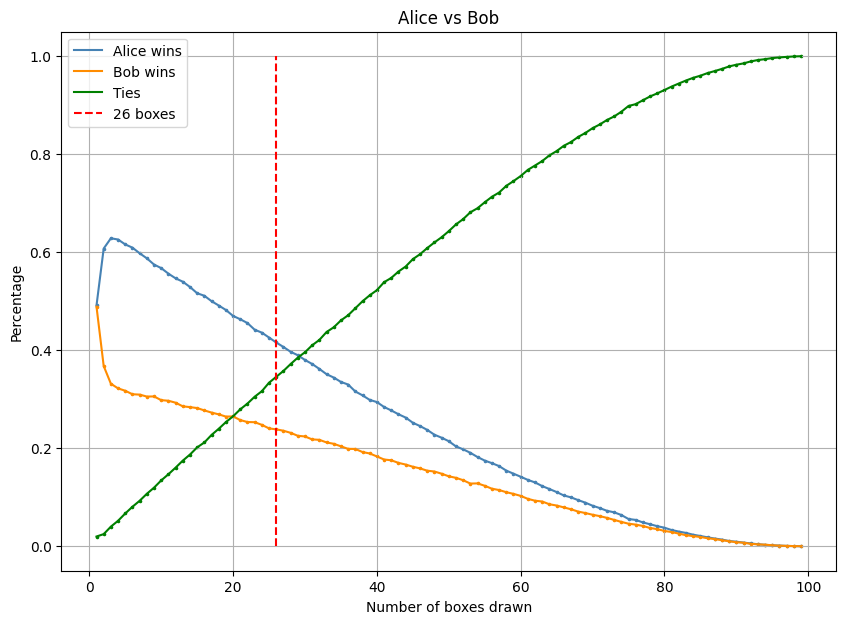

In [85]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
plt.scatter(drawn_box, per_alice, marker='.', s=10, color='steelblue')
plt.scatter(drawn_box, per_bob, marker='.', s=10, color='darkorange')
plt.scatter(drawn_box, per_tie, marker='.', s=10, color='green')
plt.plot(drawn_box, per_alice, label="Alice wins", color='steelblue')
plt.plot(drawn_box, per_bob, label="Bob wins", color='darkorange')
plt.plot(drawn_box, per_tie, label="Ties", color='green')
plt.xlabel("Number of boxes drawn")
plt.ylabel("Percentage")
plt.title("Alice vs Bob")
plt.vlines(x=26, ymin=0, ymax=1, colors='red', linestyles='dashed', label='26 boxes')
plt.legend()
plt.grid(True)
plt.show()

## Testing 2d distribution of present 1 and present 2 with win rate

In [5]:
Num = 2
total = 100000
count_alice_win = 0
count_bob_win = 0
count_tie = 0
last_box_alice, last_box_bob = [], []
last_box_tie = []
for i in range(total):
    alice, bob = 0, 0
    po_box = np.random.choice(100, size=int(Num), replace=False) + 1
    alice = max(po_box)
    index = po_box % 2 != 0
    odd_list = po_box[index]

    index2 = po_box % 2 == 0
    even_list = po_box[index2]

    if len(odd_list) == len(po_box):
        bob = (max(odd_list)+1) / 2
    else:
        bob = 50 + (max(even_list)/2)

    if alice > bob: # bob wins
        count_bob_win += 1
        last_box_bob.append(bob)
    elif alice == bob: # tie
        count_tie += 1
        last_box_tie.append(alice)
    else: # alice wins
        count_alice_win += 1
        last_box_alice.append(alice)

print(f"Alice wins: {(count_alice_win)/(total)}, Bob wins: {(count_bob_win)/(total)}, Ties: {count_tie/total}")

# per_alice.append((count_alice_win)/(total))
# per_bob.append((count_bob_win)/(total))
# per_tie.append(count_tie/total)

Alice wins: 0.60651, Bob wins: 0.36764, Ties: 0.02585


Text(0, 0.5, 'Gift 2')

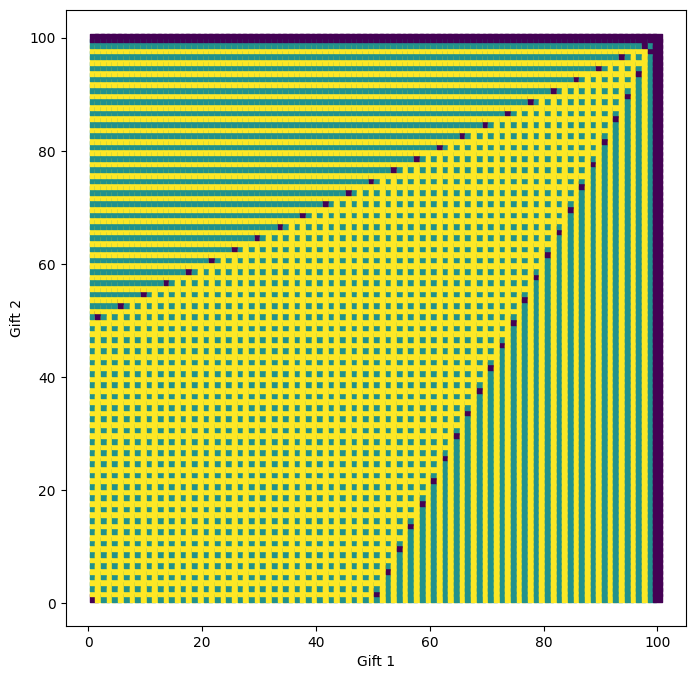

In [19]:
plt.figure(figsize=(8, 8))
plt.scatter(np.array(po_boxes)[:, 0], np.array(po_boxes)[:, 1], c=np.array(po_boxes)[:, 2], cmap='viridis', marker='s')
plt.xlabel('Gift 1')
plt.ylabel('Gift 2')

In [ ]:
Num = 26
total = 100000
count_alice_win = 0
count_bob_win = 0
count_tie = 0
alast, blast, tlast = [], [], []
for i in range(total):
    alice, bob = 0, 0
    po_box1 = np.random.choice(100, size=int(Num), replace=False) + 1
    po_box2 = np.random.choice(100, size=int(Num), replace=False) + 1
    alice = max(po_box)
    index = po_box % 2 != 0
    odd_list = po_box[index]

    index2 = po_box % 2 == 0
    even_list = po_box[index2]

    if len(odd_list) == len(po_box):
        bob = (max(odd_list)+1) / 2
    else:
        bob = 50 + (max(even_list)/2)

    if alice > bob: # bob wins
        count_bob_win += 1
        blast.append(bob)
    elif alice == bob: # tie
        count_tie += 1
        tlast.append(alice)
    else: # alice wins
        count_alice_win += 1
        alast.append(alice)

print(f"Alice wins: {(count_alice_win)/(total)}, Bob wins: {(count_bob_win)/(total)}, Ties: {count_tie/total}")

In [5]:
Num = 26
total = 100000
count_alice_win = 0
count_bob_win = 0
count_tie = 0
alast, blast, tlast = [], [], []
for i in range(total):
    alice, bob = 0, 0
    po_box = np.random.choice(100, size=int(Num), replace=False) + 1
    alice = max(po_box)
    index = po_box % 2 != 0
    odd_list = po_box[index]

    index2 = po_box % 2 == 0
    even_list = po_box[index2]

    if len(odd_list) == len(po_box):
        bob = (max(odd_list)+1) / 2
    else:
        bob = 50 + (max(even_list)/2)

    if alice > bob: # bob wins
        count_bob_win += 1
        blast.append(bob)
    elif alice == bob: # tie
        count_tie += 1
        tlast.append(alice)
    else: # alice wins
        count_alice_win += 1
        alast.append(alice)

print(f"Alice wins: {(count_alice_win)/(total)}, Bob wins: {(count_bob_win)/(total)}, Ties: {count_tie/total}")

# per_alice.append((count_alice_win)/(total))
# per_bob.append((count_bob_win)/(total))
# per_tie.append(count_tie/total)

Alice wins: 0.41752, Bob wins: 0.24061, Ties: 0.34187


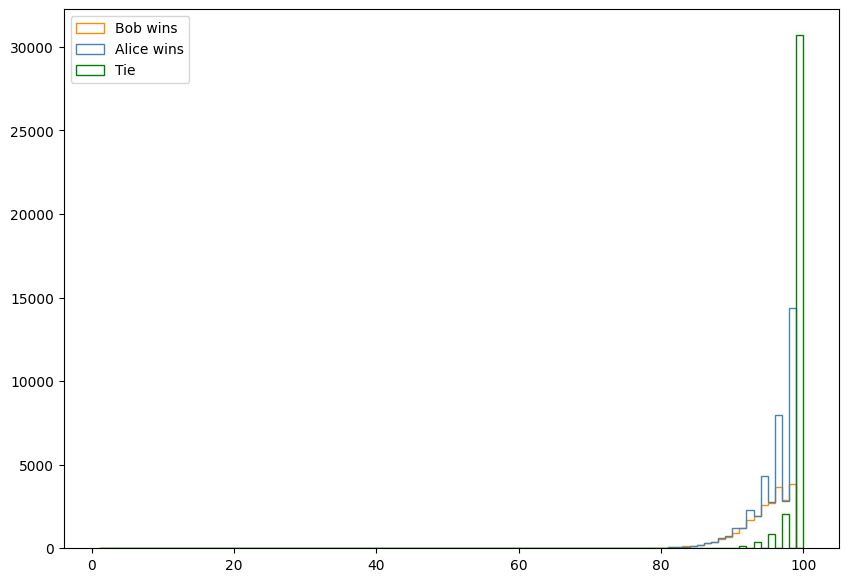

In [8]:
plt.figure(figsize=(10, 7))
plt.hist(blast, bins=np.linspace(1, 100, 100), histtype='step', label='Bob wins', color='darkorange')
plt.hist(alast, bins=np.linspace(1, 100, 100), histtype='step', label='Alice wins', color='steelblue')
plt.hist(tlast, bins=np.linspace(1, 100, 100), histtype='step', label='Tie', color='green')
plt.legend()